In [1]:
import warnings;
warnings.simplefilter('ignore')
from dcr import *

In [2]:
%matplotlib inline
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (16,9)
plt.rcParams.update({'font.size': 16})

In [4]:
np.random.seed(1234) 
n = 2000 
sigma = 1  
mean_X = [0, 0] 
cov_X = [[1, 0], [0, 1]]
X_train = np.random.multivariate_normal(mean_X, cov_X, n)  
X_test = np.random.multivariate_normal(mean_X, cov_X, n)  
bias = -1
w1 = 1 
w2 = -0.8 

def inv_logit(eta):  
    return np.exp(eta)/ (1 + np.exp(eta))  

lin_pred_train = bias + w1 * X_train[:,0] + w2 * X_train[:,1] 
lin_pred_test = bias + w1 * X_test[:,0] + w2 * X_test[:,1]  
PD_train = inv_logit(lin_pred_train)  
PD_test = inv_logit(lin_pred_test)  

y_train = np.random.binomial(1, PD_train) 
y_test = np.random.binomial(1, PD_test)  

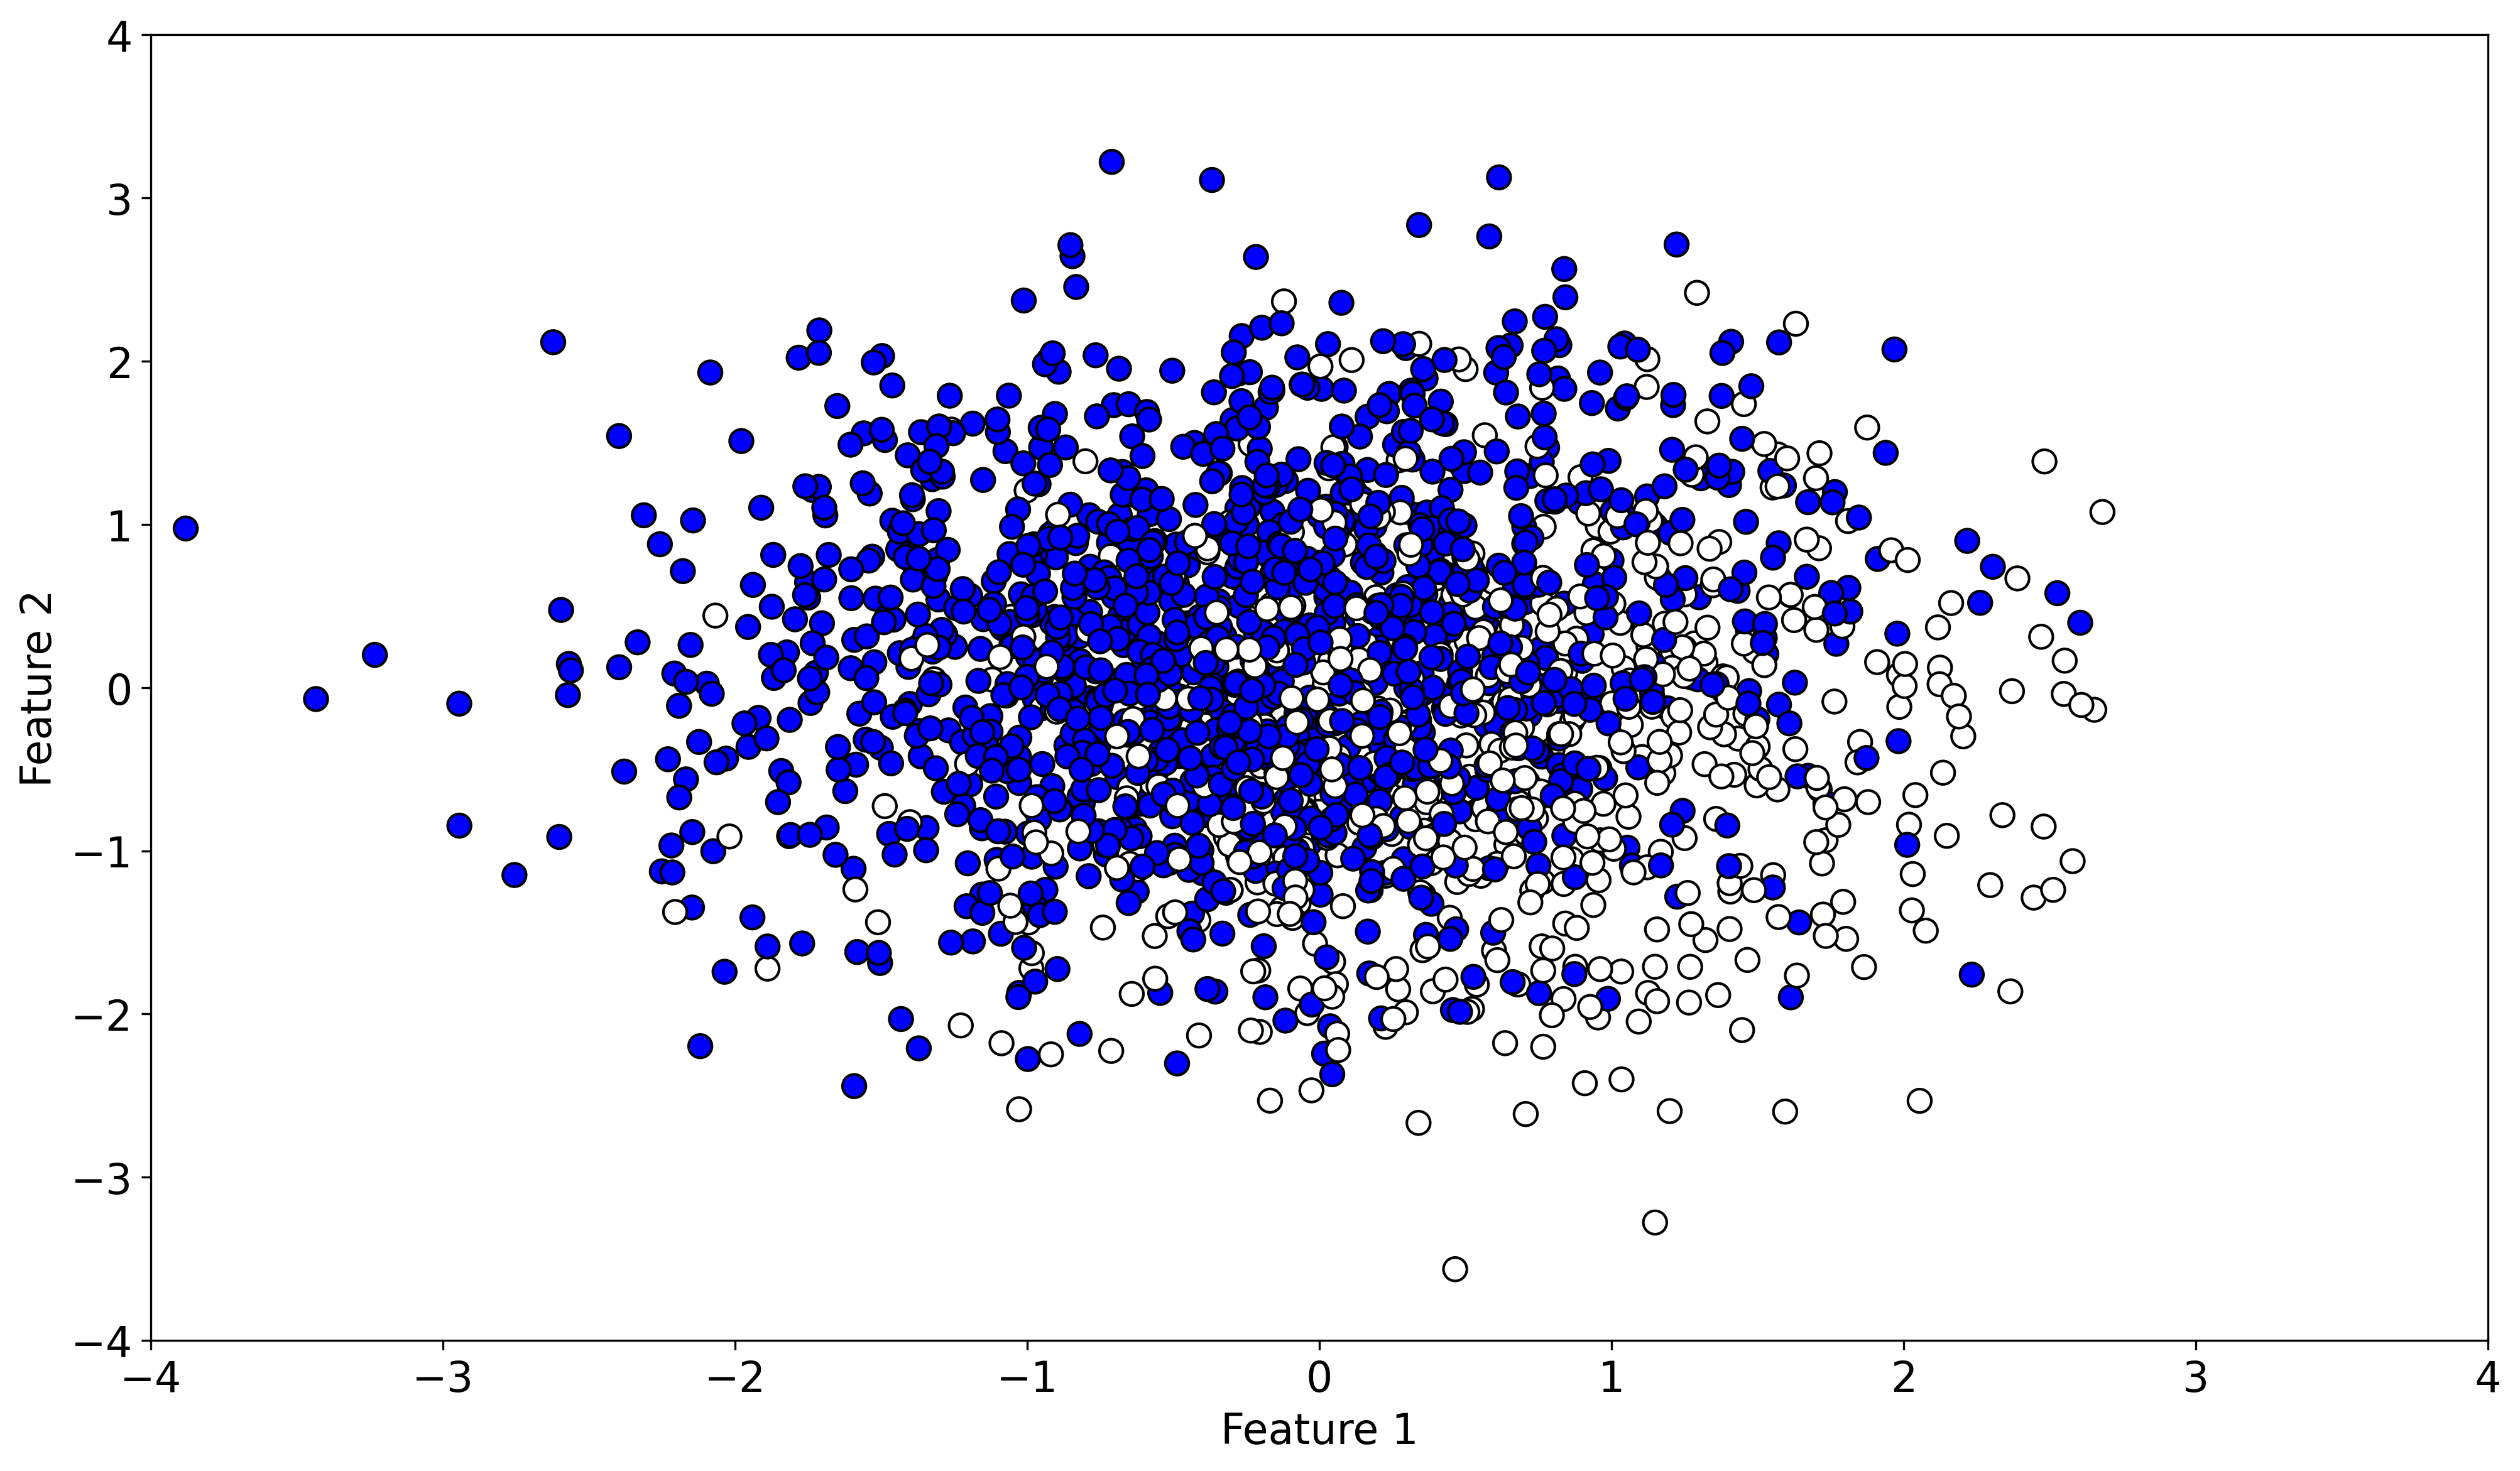

In [5]:
from matplotlib.colors import ListedColormap  
cmap_bold = ListedColormap(['#0000FF', '#00FF00','#FFFFFF']) 

plt.figure() 
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cmap_bold,  edgecolor='k', s=80) 
plt.xlim(-4, 4)  
plt.ylim(-4, 4)  

plt.xlabel('Feature 1')  
plt.ylabel('Feature 2') 
plt.show() 


In [6]:
model_lr = LogisticRegression(penalty='none', fit_intercept=True, solver='saga', n_jobs=2,  tol =1e-15, max_iter=2000)  
model_lr.fit(X_train, y_train)  
print('Coefficients:', model_lr.coef_.round(decimals=4))  
print('Intercept:', model_lr.intercept_.round(decimals=4)) 
predictions = model_lr.predict_proba(X_test)[:,1].T  
predictions_cat = model_lr.predict(X_test)  
print(classification_report(y_test,predictions_cat)) 
print(confusion_matrix(y_test,predictions_cat))  
print("Log Loss:", log_loss(y_test, predictions)) 
print("AUC:", roc_auc_score(y_test, predictions))
print("Brier score: (the smaller the better):", brier_score_loss(y_test, predictions))


Coefficients: [[ 1.0895 -0.7983]]
Intercept: [-0.9784]
              precision    recall  f1-score   support

           0       0.78      0.89      0.83      1341
           1       0.68      0.48      0.56       659

    accuracy                           0.75      2000
   macro avg       0.73      0.68      0.69      2000
weighted avg       0.74      0.75      0.74      2000

[[1194  147]
 [ 345  314]]
Log Loss: 0.5001806175080926
AUC: 0.7995844833029504
Brier score: (the smaller the better): 0.16547722815294402


In [7]:
model_nn = MLPClassifier(hidden_layer_sizes=(), random_state=2, max_iter=500,  solver='sgd', learning_rate='adaptive', learning_rate_init=0.1,  validation_fraction=0.3,  verbose=False, n_iter_no_change=10, early_stopping=False, alpha=0.01, shuffle=True)  
model_nn.fit(X_train, y_train)

MLPClassifier(alpha=0.01, hidden_layer_sizes=(), learning_rate='adaptive',
              learning_rate_init=0.1, max_iter=500, random_state=2,
              solver='sgd', validation_fraction=0.3)

In [8]:
MLPClassifier(activation='relu', alpha=0.01, batch_size='auto', beta_1=0.9,  beta_2=0.999, early_stopping=False, epsilon=1e-08,  hidden_layer_sizes=(), learning_rate='adaptive',  learning_rate_init=0.1, max_fun=15000, max_iter=500, momentum=0.9,  n_iter_no_change=10, nesterovs_momentum=True, power_t=0.5,  random_state=2, shuffle=True, solver='sgd', tol=0.0001,  validation_fraction=0.3, verbose=False, warm_start=False)

MLPClassifier(alpha=0.01, hidden_layer_sizes=(), learning_rate='adaptive',
              learning_rate_init=0.1, max_iter=500, random_state=2,
              solver='sgd', validation_fraction=0.3)

In [9]:
print('Weights:', np.array(model_nn.coefs_).round(4)) 
print('Biases:', np.array(model_nn.intercepts_).round(4)) 

Weights: [[[ 1.0889]
  [-0.7982]]]
Biases: [[-0.9785]]


In [10]:
predictions = model_nn.predict_proba(X_test)[:,1].T 
predictions_cat = model_nn.predict(X_test) 
print(classification_report(y_test,predictions_cat)) 
print(confusion_matrix(y_test,predictions_cat))  
print("Log Loss:", log_loss(y_test, predictions))  
print("AUC:", roc_auc_score(y_test, predictions))  
print("Brier score: (the smaller the better):", brier_score_loss(y_test, predictions))

              precision    recall  f1-score   support

           0       0.77      0.89      0.83      1341
           1       0.68      0.47      0.56       659

    accuracy                           0.75      2000
   macro avg       0.73      0.68      0.69      2000
weighted avg       0.74      0.75      0.74      2000

[[1194  147]
 [ 347  312]]
Log Loss: 0.5001799406611452
AUC: 0.7995833517215315
Brier score: (the smaller the better): 0.16547766658996946


In [11]:
from sklearn.datasets import make_circles  
np.random.seed(1234) 
n = 200 
tmp1 = make_circles(n_samples=n, noise=0.2, factor=0.5, random_state=1)  
X_train = tmp1[0]  
y_train = tmp1[1]  
tmp2 = make_circles(n_samples=n, noise=0.2, factor=0.5, random_state=2)  
X_test = tmp2[0] 
y_test = tmp2[1] 

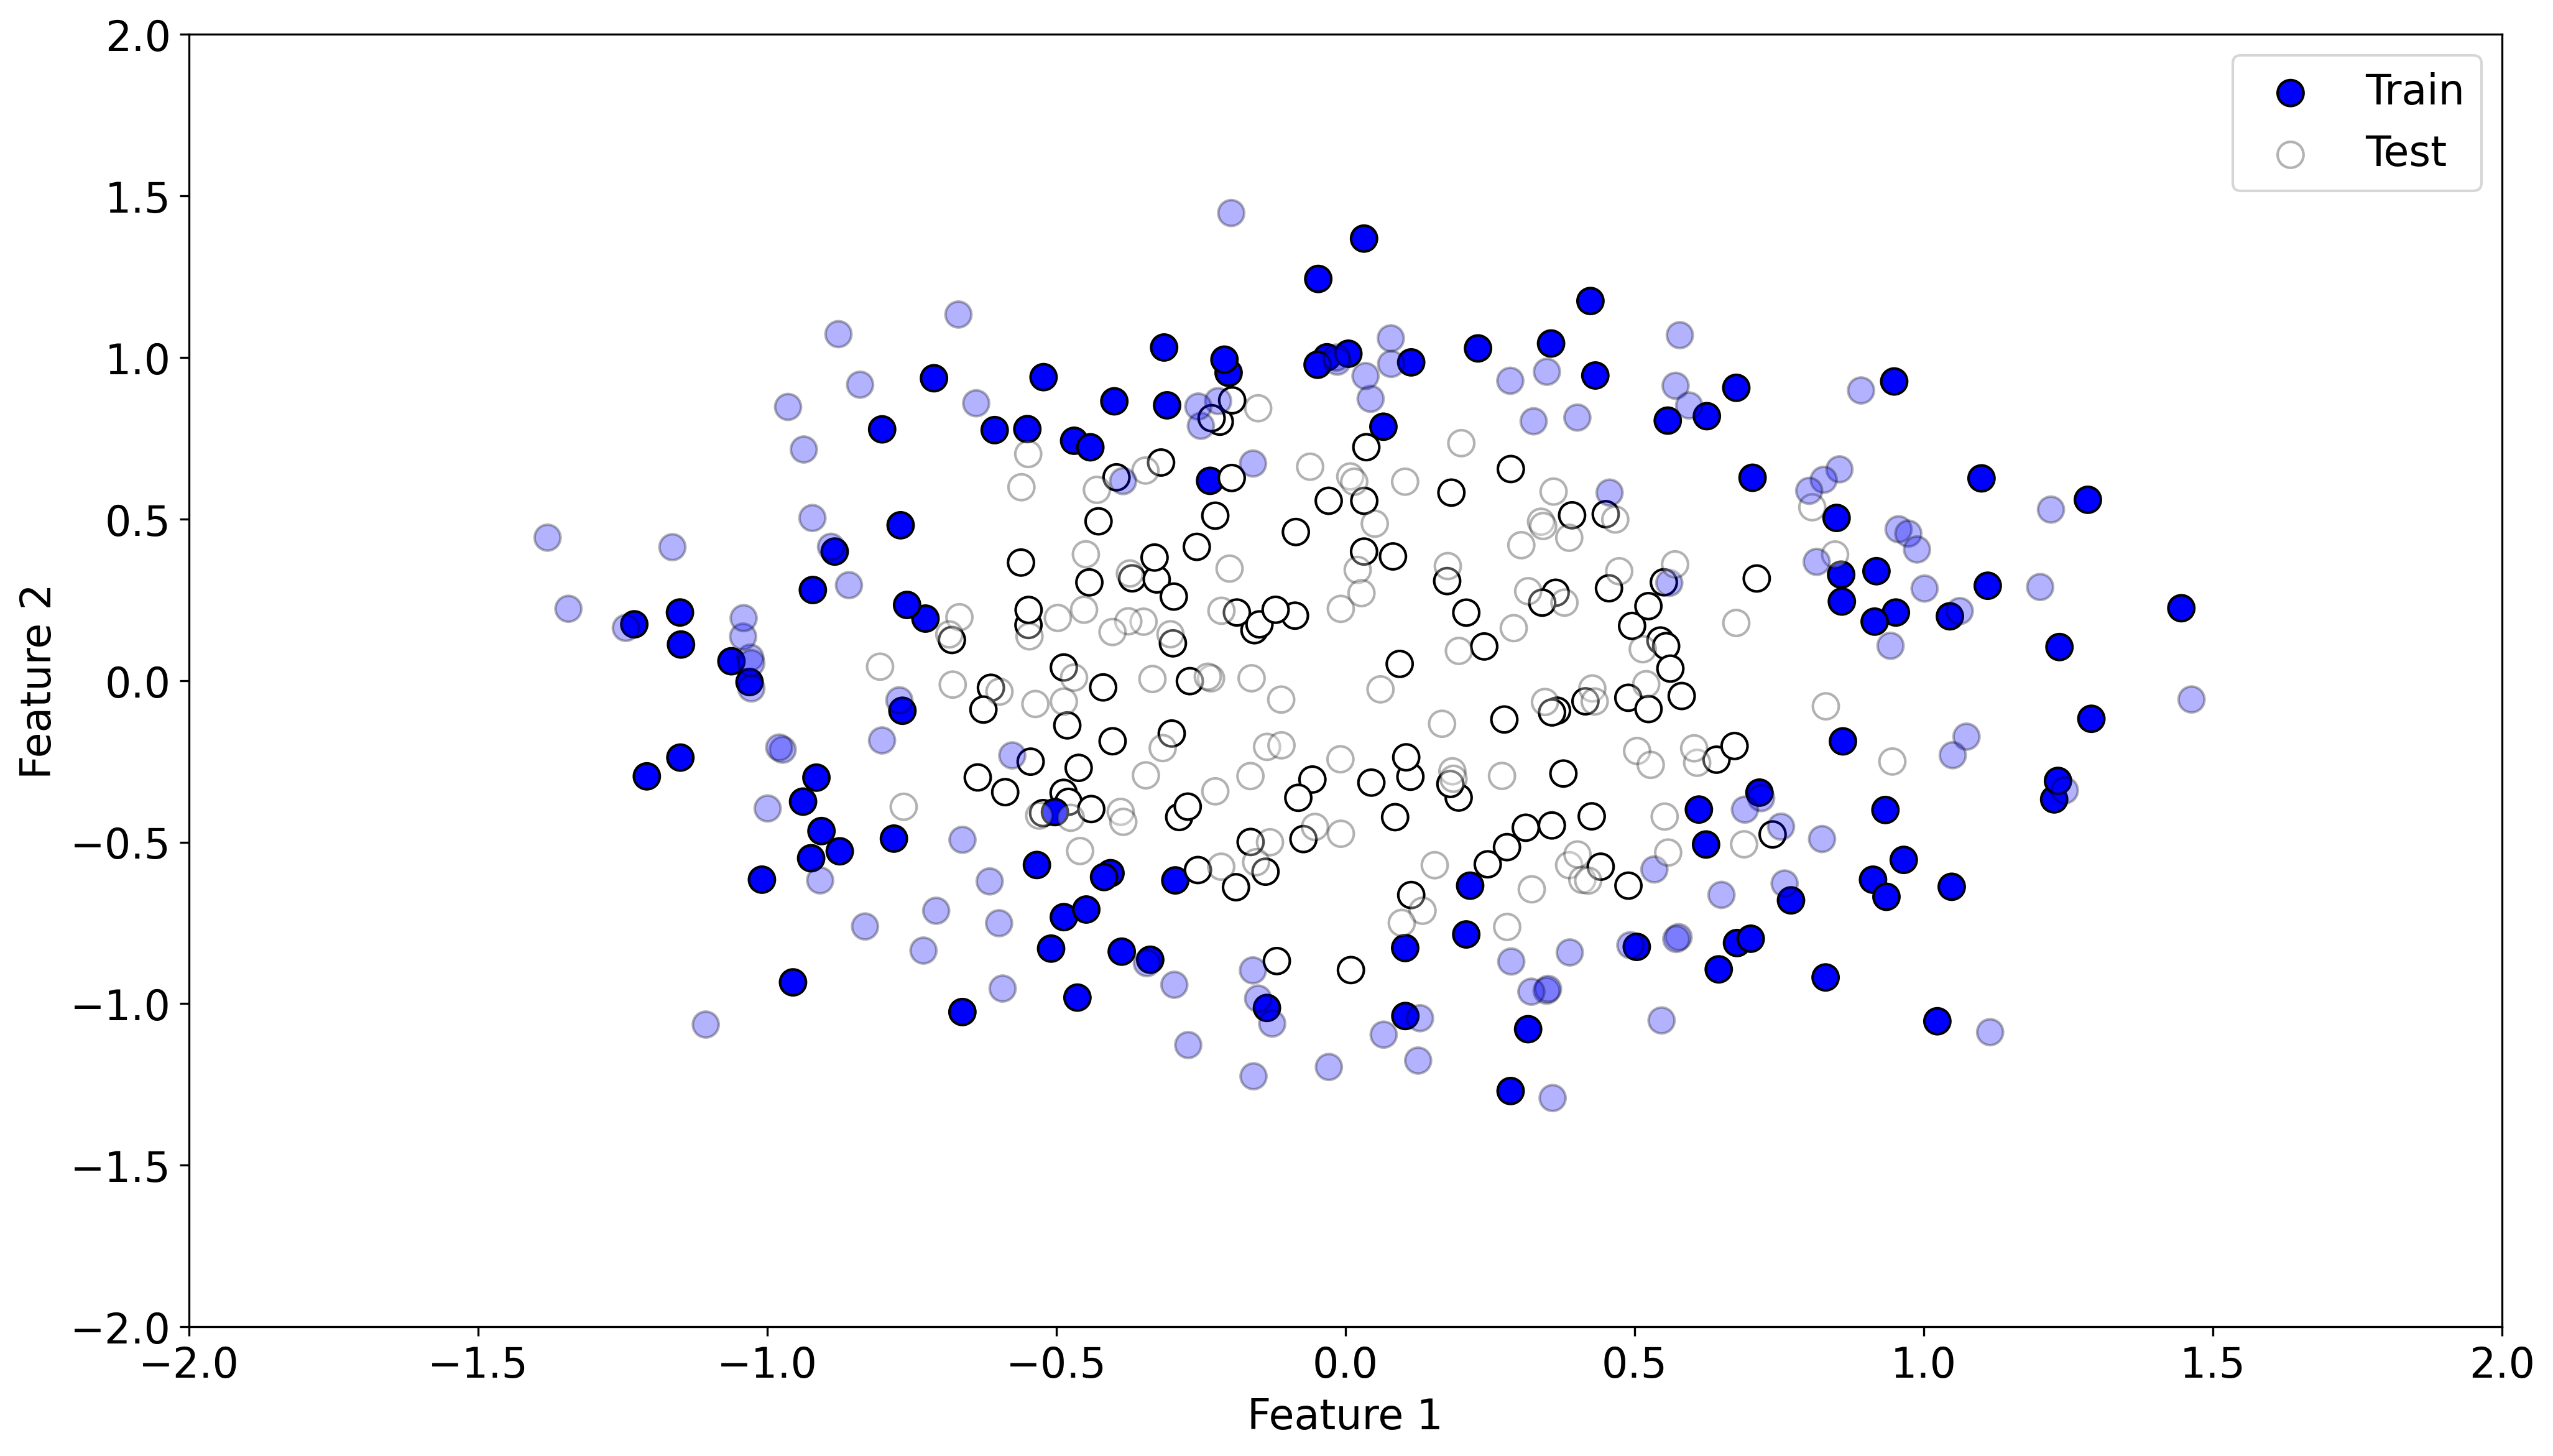

In [13]:
plt.figure()  
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cmap_bold,  edgecolor='k', s=100, label='Train')  
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=cmap_bold, alpha=0.3, edgecolor='k', s=100, label='Test')
plt.xlim(-2, 2) 
plt.ylim(-2, 2)
plt.xlabel('Feature 1') 
plt.ylabel('Feature 2')  
plt.legend(loc='best') 
plt.show() 

In [14]:
model_lr = LogisticRegression(penalty='none', fit_intercept=True, solver='saga', n_jobs=2,  tol=1e-15, max_iter=2000) 
model_lr.fit(X_train, y_train)  

print(model_lr.coef_.round(decimals=4)) 
print(model_lr.intercept_.round(decimals=4)) 
predictions = model_lr.predict_proba(X_test)[:,1].T 
predictions_cat = model_lr.predict(X_test)  
print(classification_report(y_test,predictions_cat))  
print(confusion_matrix(y_test,predictions_cat)) 
print("Log Loss:", log_loss(y_test, predictions))  
print("AUC:", roc_auc_score(y_test, predictions))  
print("Brier score: (the smaller the better):", brier_score_loss(y_test, predictions)) 

[[-0.1341 -0.0327]]
[0.0022]
              precision    recall  f1-score   support

           0       0.50      0.51      0.50       100
           1       0.50      0.49      0.49       100

    accuracy                           0.50       200
   macro avg       0.50      0.50      0.50       200
weighted avg       0.50      0.50      0.50       200

[[51 49]
 [51 49]]
Log Loss: 0.6948995583035551
AUC: 0.4894
Brier score: (the smaller the better): 0.2508742518229471


In [15]:
model_nn = MLPClassifier(hidden_layer_sizes=(5), random_state=2, max_iter=1000, warm_start=True,  activation='tanh',  solver='sgd', learning_rate='adaptive', learning_rate_init=0.1,  validation_fraction=0.3,  verbose=False, n_iter_no_change=10, early_stopping=False, alpha=0.01, shuffle=True) 
model_nn.fit(X_train, y_train)  

MLPClassifier(activation='tanh', alpha=0.01, hidden_layer_sizes=5,
              learning_rate='adaptive', learning_rate_init=0.1, max_iter=1000,
              random_state=2, solver='sgd', validation_fraction=0.3,
              warm_start=True)

In [16]:
MLPClassifier(activation='tanh', alpha=0.01, batch_size='auto', beta_1=0.9,  beta_2=0.999, early_stopping=False, epsilon=1e-08,  hidden_layer_sizes=5, learning_rate='adaptive',  learning_rate_init=0.1, max_fun=15000, max_iter=1000,  momentum=0.9, n_iter_no_change=10, nesterovs_momentum=True,  power_t=0.5, random_state=2, shuffle=True, solver='sgd',  tol=0.0001, validation_fraction=0.3, verbose=False,  warm_start=True)

MLPClassifier(activation='tanh', alpha=0.01, hidden_layer_sizes=5,
              learning_rate='adaptive', learning_rate_init=0.1, max_iter=1000,
              random_state=2, solver='sgd', validation_fraction=0.3,
              warm_start=True)

In [18]:
total_parameters = 0  

for i in range(0,len(model_nn.coefs_)):  
    print('Layer connection:', i, '| weight matrix shape:', np.array(model_nn.coefs_[i]).shape,  '| bias matrix shape:', np.array(model_nn.intercepts_[i]).shape) 
    total_parameters = total_parameters + np.array(model_nn.coefs_[i]).shape[0] * np.array(  model_nn.coefs_[i]).shape[1] + model_nn.intercepts_[i].shape[0] 
    
print('Total number of parameters:', total_parameters)


Layer connection: 0 | weight matrix shape: (2, 5) | bias matrix shape: (5,)
Layer connection: 1 | weight matrix shape: (5, 1) | bias matrix shape: (1,)
Total number of parameters: 21


In [19]:
predictions = model_nn.predict_proba(X_test)[:,1].T  
predictions_cat = model_nn.predict(X_test)  
print(classification_report(y_test,predictions_cat))  
print(confusion_matrix(y_test,predictions_cat))  
print("Log Loss:", log_loss(y_test, predictions))  
print("AUC:", roc_auc_score(y_test, predictions)) 
print("Brier score: (the smaller the better):", brier_score_loss(y_test, predictions))

              precision    recall  f1-score   support

           0       0.85      0.92      0.88       100
           1       0.91      0.84      0.87       100

    accuracy                           0.88       200
   macro avg       0.88      0.88      0.88       200
weighted avg       0.88      0.88      0.88       200

[[92  8]
 [16 84]]
Log Loss: 0.27214081352294306
AUC: 0.9551
Brier score: (the smaller the better): 0.08273066180945905


In [20]:
from dcr import *  

data = data.query('time <=40').copy()  
_, data_train, data_test, X_train_scaled, X_test_scaled, y_train, y_test = dataprep(data,  depvar='default_time', splitvar='time', threshold=26)

In [21]:
print('Observations in train data:', X_train_scaled.shape)  
print('Observations in test data:', X_test_scaled.shape)  
print('Default rate in train data:', np.mean(y_train).round(4))  
print('Default rate in test data:', np.mean(y_test).round(4))
 

Observations in train data: (12702, 11)
Observations in test data: (27368, 11)
Default rate in train data: 0.0104
Default rate in test data: 0.0355


In [22]:
np.random.seed(12345)  
model_nn = MLPClassifier(hidden_layer_sizes=(3), random_state=2, max_iter=3000, warm_start=True,  activation='relu',  solver='sgd', learning_rate='adaptive', learning_rate_init=0.1,  validation_fraction=0.3,  verbose=False, n_iter_no_change=10, early_stopping=False, alpha=0.001, shuffle=True) 
model_nn.fit(X_train_scaled, y_train) 

MLPClassifier(alpha=0.001, hidden_layer_sizes=3, learning_rate='adaptive',
              learning_rate_init=0.1, max_iter=3000, random_state=2,
              solver='sgd', validation_fraction=0.3, warm_start=True)

In [23]:
MLPClassifier(activation='relu', alpha=0.001, batch_size='auto', beta_1=0.9,  beta_2=0.999, early_stopping=False, epsilon=1e-08,  hidden_layer_sizes=3, learning_rate='adaptive',  learning_rate_init=0.1, max_fun=15000, max_iter=3000,  momentum=0.9, n_iter_no_change=10, nesterovs_momentum=True,  power_t=0.5, random_state=2, shuffle=True, solver='sgd',  tol=0.0001, validation_fraction=0.3, verbose=False,  warm_start=True)

MLPClassifier(alpha=0.001, hidden_layer_sizes=3, learning_rate='adaptive',
              learning_rate_init=0.1, max_iter=3000, random_state=2,
              solver='sgd', validation_fraction=0.3, warm_start=True)

In [24]:
total_parameters = 0  
for i in range(0,len(model_nn.coefs_)):  
    print('Layer connection:', i, '| weight matrix shape:', np.array(model_nn.coefs_[i]).  shape,  '| bias matrix shape:', np.array(model_nn.intercepts_[i]).shape) 
    total_parameters = total_parameters + np.array(model_nn.coefs_[i]).shape[0]*np.array(  model_nn.coefs_[i]).shape[1] + model_nn.intercepts_[i].shape[0]  
    
print('Total number of parameters:', total_parameters)

Layer connection: 0 | weight matrix shape: (11, 3) | bias matrix shape: (3,)
Layer connection: 1 | weight matrix shape: (3, 1) | bias matrix shape: (1,)
Total number of parameters: 40


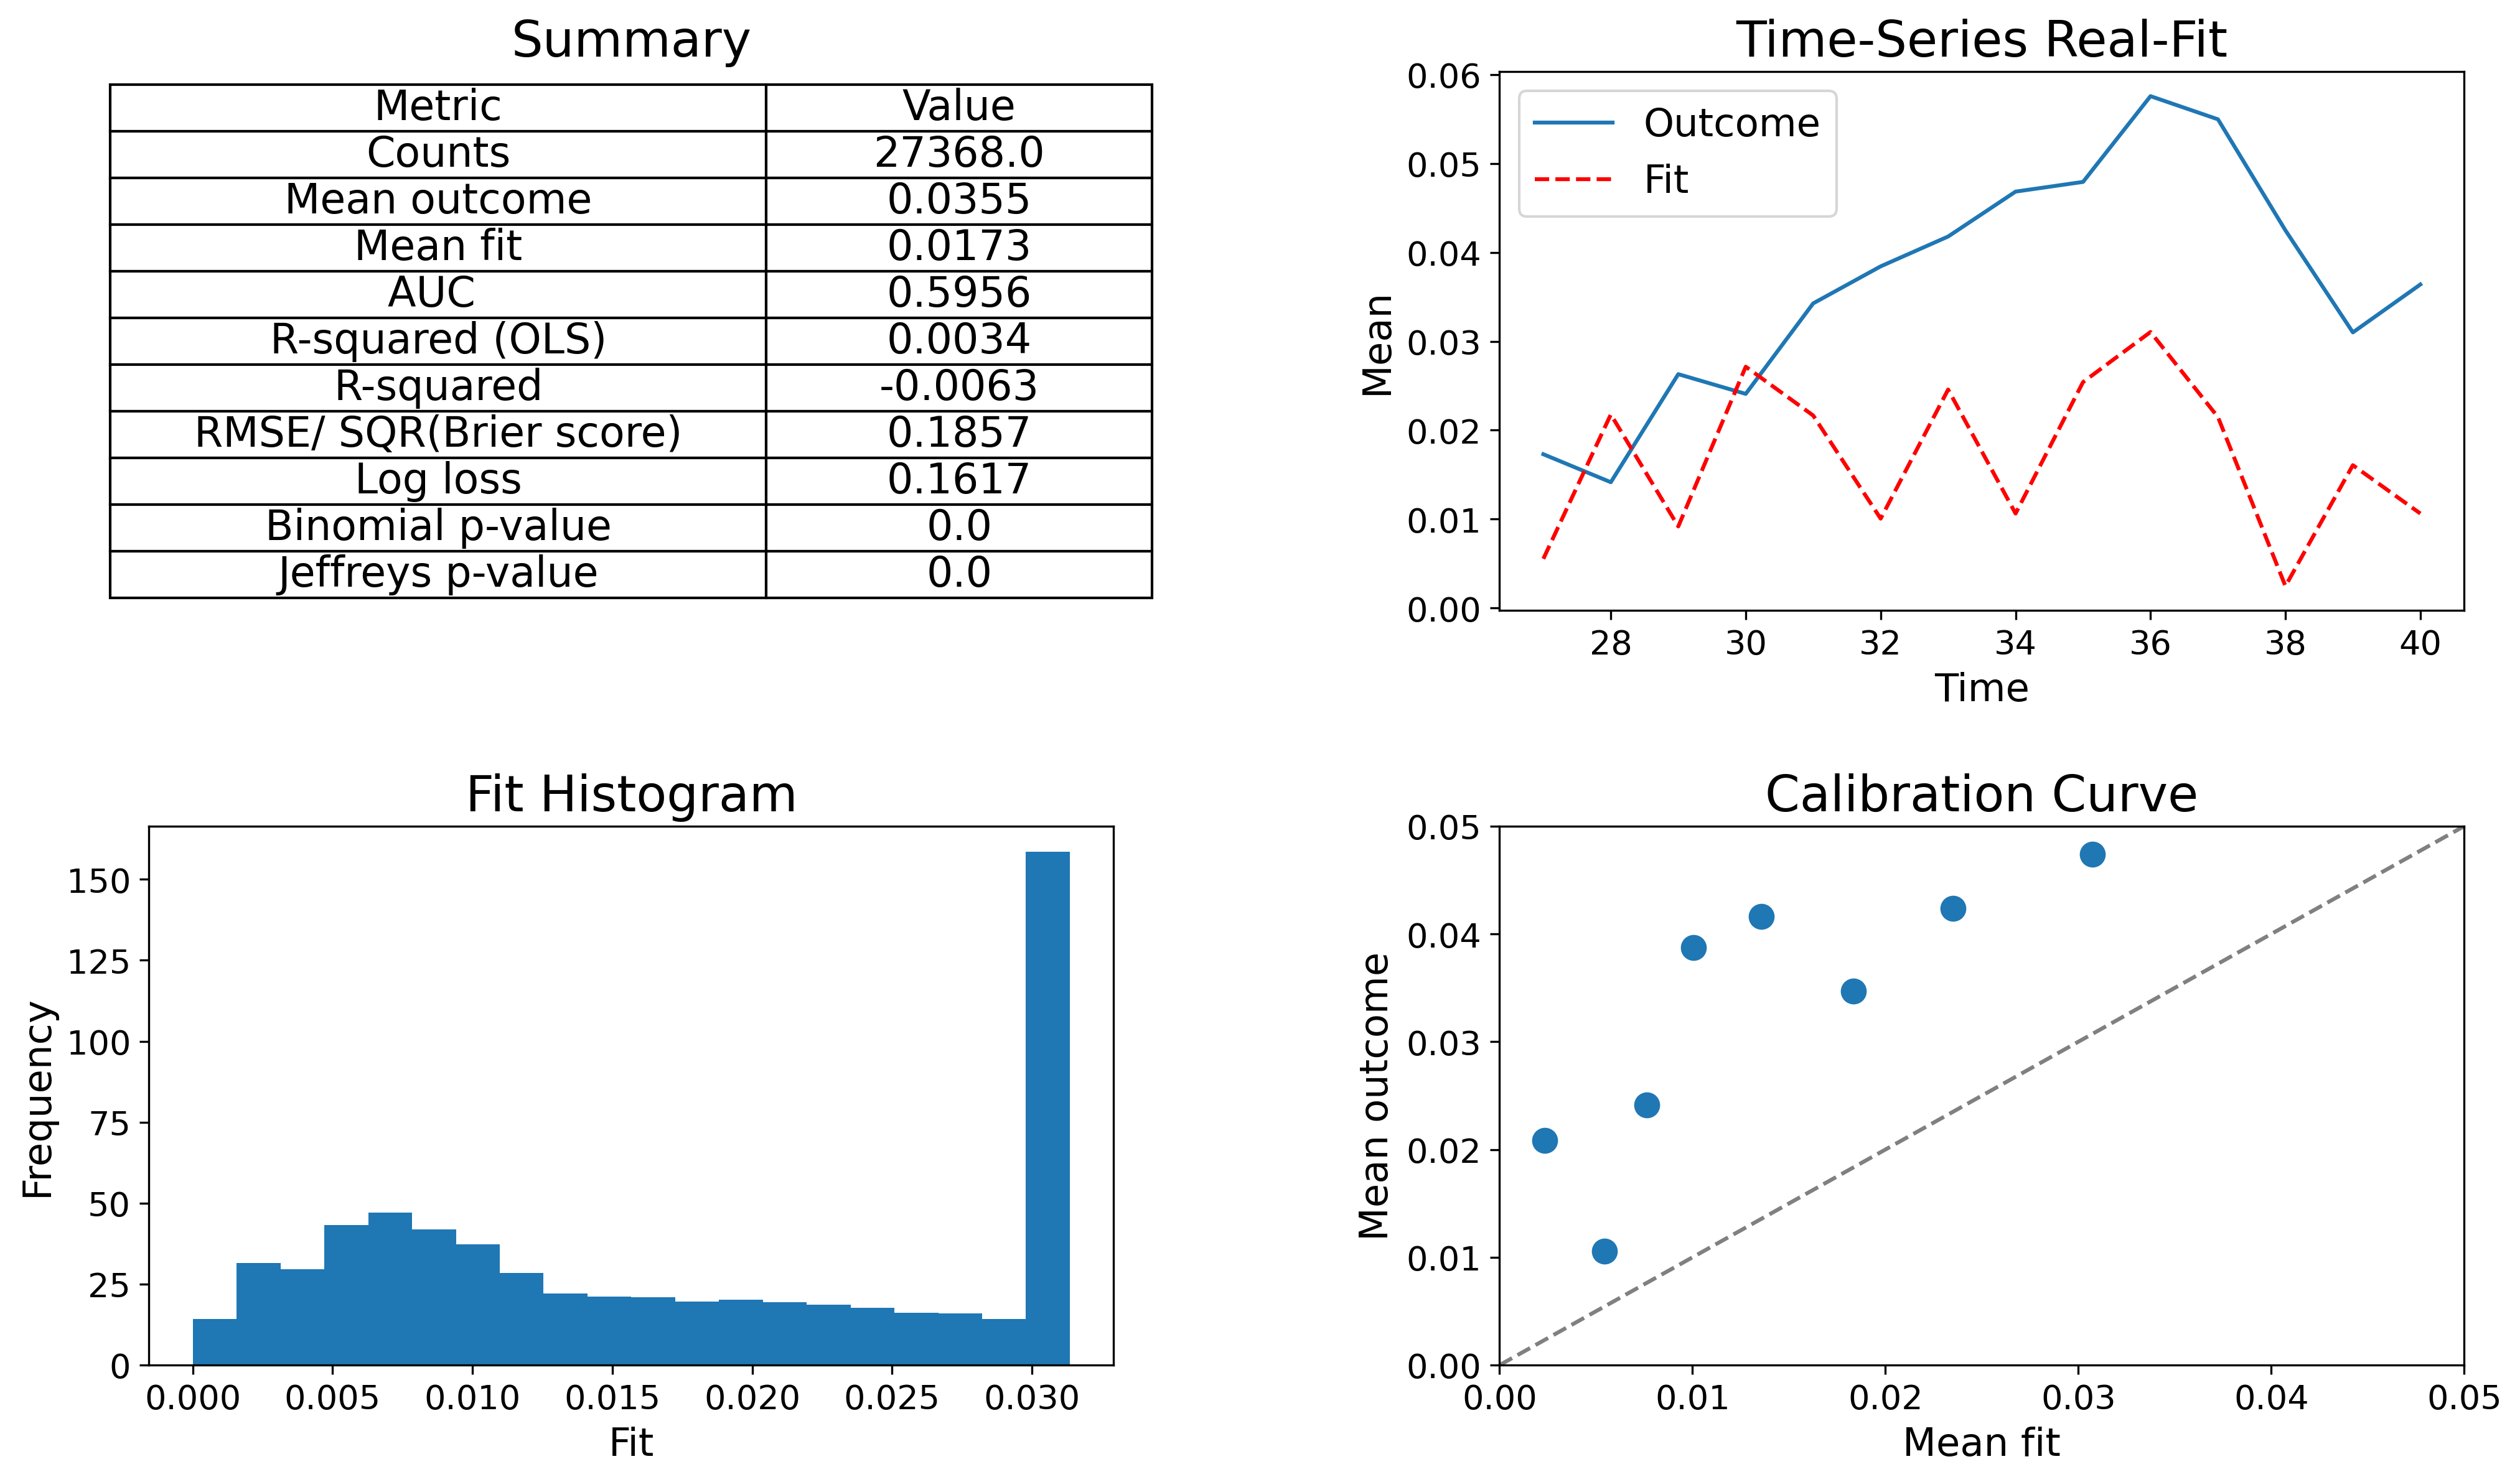

In [25]:
predictions_test = model_nn.predict_proba(X_test_scaled)[:,1].T  
validation(predictions_test, y_test, data_test['time'].values) 
AUC_nn = roc_auc_score(y_test, predictions_test).round(4) 
sqrt_brier_nn = np.sqrt(brier_score_loss(y_test, predictions_test)).round(4)

In [26]:
model_nn_cv=MLPClassifier(random_state=2, max_iter=3000, warm_start=True,  learning_rate='adaptive', validation_fraction=0.3,  verbose=False, n_iter_no_change=10, early_stopping=True, shuffle=  True) 
param_grid = {'hidden_layer_sizes':[(1), (2), (3), (13), (3,2) ,(13,26), (13,100,), (13,1)  ],  'learning_rate_init':[0.01, 0.1],  'alpha':[0.001],  'activation': ['relu', 'tanh'],  'solver': ['sgd']}  
gs_nn= GridSearchCV(estimator =model_nn_cv, param_grid = param_grid, n_jobs=2, cv=5,  verbose=0, scoring='roc_auc')  
gs_nn.fit(X_train_scaled, y_train)  
print(gs_nn.best_params_, gs_nn.best_score_)  

filename = 'Mortgage_nn_GridSearch.sav'  
pickle.dump(gs_nn, open(filename, 'wb'))  

{'activation': 'tanh', 'alpha': 0.001, 'hidden_layer_sizes': (13, 1), 'learning_rate_init': 0.1, 'solver': 'sgd'} 0.7450480160106254


In [27]:
filename = 'Mortgage_nn_GridSearch.sav'  
gs_nn = pickle.load(open(filename, 'rb')) 
print(gs_nn.best_params_)  
model_nn_best = MLPClassifier(gs_nn.best_params_.get('hidden_layer_sizes'),  activation = gs_nn.best_params_.get('activation'),  solver=gs_nn.best_params_.get('solver'),  learning_rate_init=gs_nn.best_params_.get('learning_rate_init'  ),  alpha=gs_nn.best_params_.get('alpha'),  learning_rate='adaptive',  random_state=2, max_iter=3000, warm_start=False,  validation_fraction=0.3,  verbose=False, n_iter_no_change=10, early_stopping=False,  shuffle=True)  
model_nn_best.fit(X_train_scaled, y_train)

{'activation': 'tanh', 'alpha': 0.001, 'hidden_layer_sizes': (13, 1), 'learning_rate_init': 0.1, 'solver': 'sgd'}


MLPClassifier(activation='tanh', alpha=0.001, hidden_layer_sizes=(13, 1),
              learning_rate='adaptive', learning_rate_init=0.1, max_iter=3000,
              random_state=2, solver='sgd', validation_fraction=0.3)

In [28]:
MLPClassifier(activation='tanh', alpha=0.001, batch_size='auto', beta_1=0.9,  beta_2=0.999, early_stopping=False, epsilon=1e-08,  hidden_layer_sizes=(13, 1), learning_rate='adaptive',  learning_rate_init=0.01, max_fun=15000, max_iter=3000,  momentum=0.9, n_iter_no_change=10, nesterovs_momentum=True,  power_t=0.5, random_state=2, shuffle=True, solver='sgd',  tol=0.0001, validation_fraction=0.3, verbose=False,  warm_start=False) 

MLPClassifier(activation='tanh', alpha=0.001, hidden_layer_sizes=(13, 1),
              learning_rate='adaptive', learning_rate_init=0.01, max_iter=3000,
              random_state=2, solver='sgd', validation_fraction=0.3)

In [29]:
total_parameters = 0  
for i in range(0,len(model_nn_best.coefs_)):  
    print('Layer connection:', i, '| weight matrix shape:', np.array(model_nn_best.coefs_[i  ]).shape,  '| bias matrix shape:', np.array(model_nn_best.intercepts_[i]).shape)  
    total_parameters = total_parameters + np.array(model_nn_best.coefs_[i]).shape[0]*np.array(model_nn_best.coefs_[i]).shape[1] + model_nn_best.intercepts_[i].shape[0]  
print('Total number of parameters:', total_parameters)

Layer connection: 0 | weight matrix shape: (11, 13) | bias matrix shape: (13,)
Layer connection: 1 | weight matrix shape: (13, 1) | bias matrix shape: (1,)
Layer connection: 2 | weight matrix shape: (1, 1) | bias matrix shape: (1,)
Total number of parameters: 172


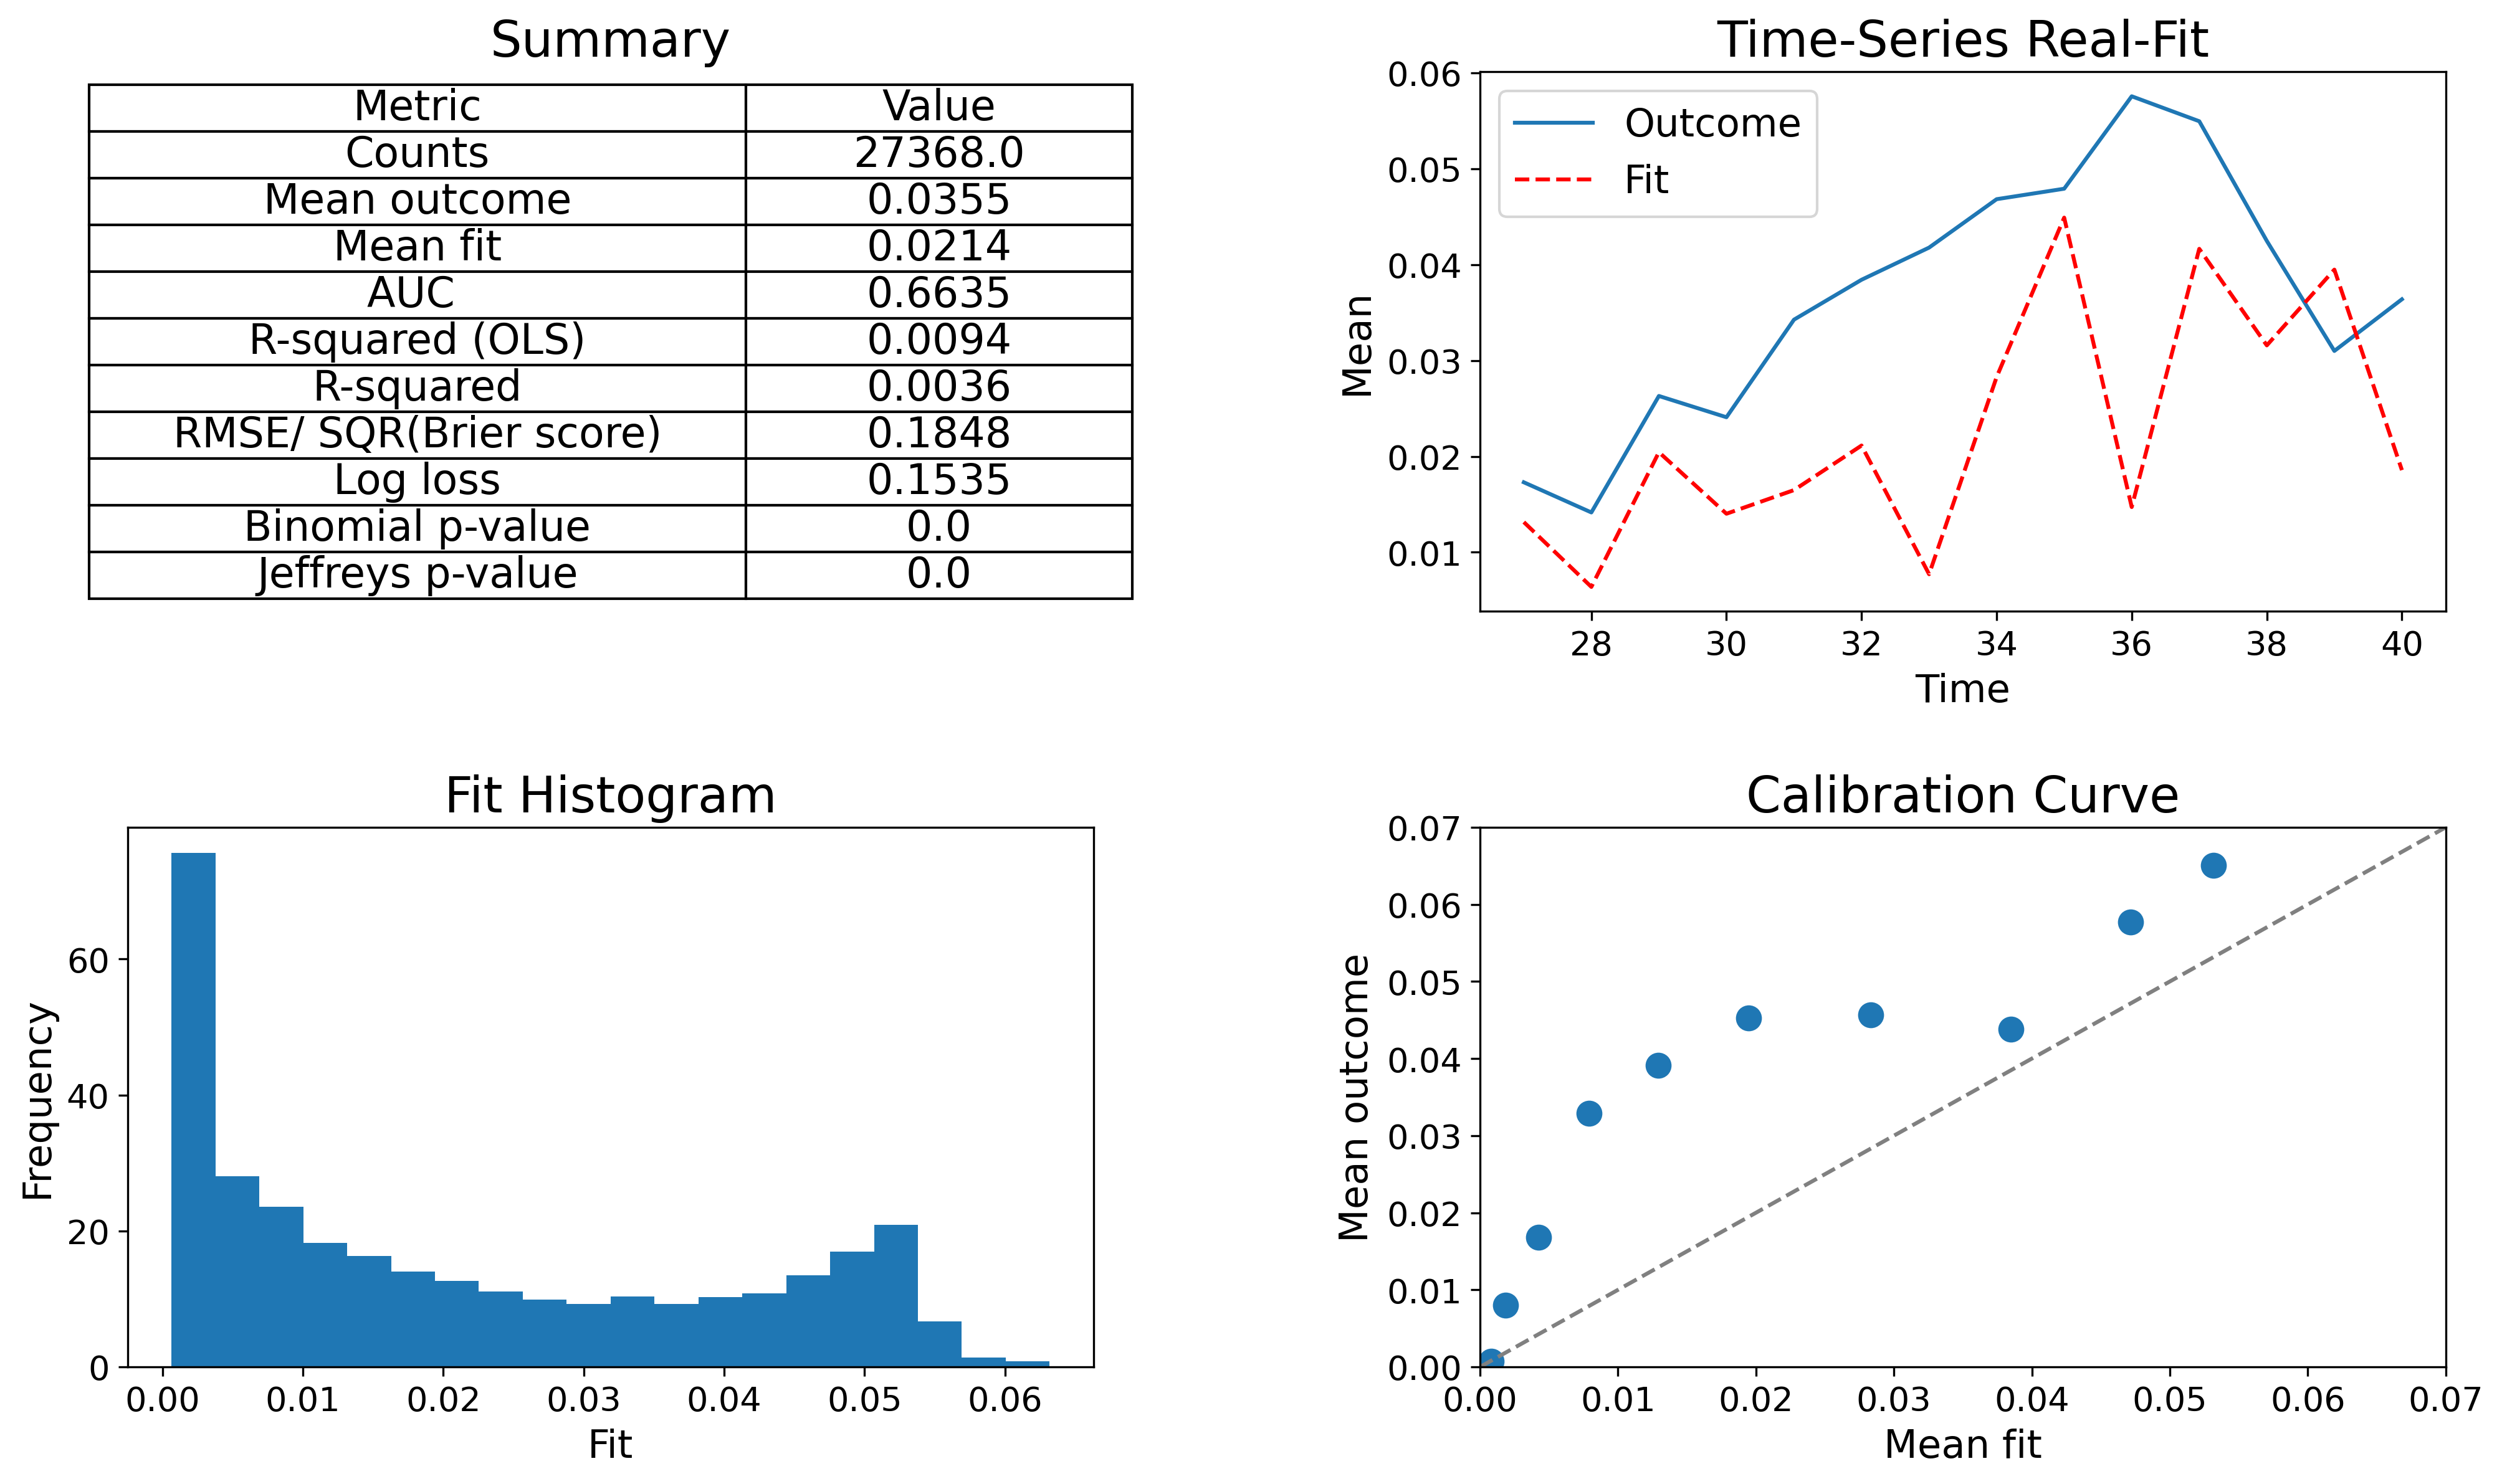

In [30]:
predictions_test = model_nn_best.predict_proba(X_test_scaled)[:,1].T  

validation(predictions_test, y_test, data_test['time'].values)  
AUC_nn_best1 = roc_auc_score(y_test, predictions_test).round(4) 
sqrt_brier_nn_best1 = np.sqrt(brier_score_loss(y_test, predictions_test)).round(4) 


In [31]:
model_nn_cv = MLPClassifier(random_state=2, max_iter=3000, warm_start=False,  learning_rate='adaptive', validation_fraction=0.3,  verbose=False, n_iter_no_change=10, early_stopping=True)  
params_grid = {'hidden_layer_sizes': sp_randint(1,100),  'learning_rate_init': expon(scale=1),  'alpha': expon(scale=1),  'activation': ['relu', 'tanh'],  'solver': ['adam', 'sgd']}  
rs_nn = RandomizedSearchCV(model_nn_cv, params_grid, verbose=0, n_iter=100, n_jobs=2, cv=5,  scoring='roc_auc')  
rs_nn.fit(X_train_scaled, y_train) 

print(rs_nn.best_params_, rs_nn.best_score_) 

filename = 'Mortgage_nn_RandomizedGridSearch.sav' 
pickle.dump(rs_nn, open(filename, 'wb'))

{'activation': 'relu', 'alpha': 0.31630485694503196, 'hidden_layer_sizes': 1, 'learning_rate_init': 0.26805022969618175, 'solver': 'adam'} 0.7656660025792881


In [32]:
filename = 'Mortgage_nn_RandomizedGridSearch.sav'
rs_nn = pickle.load(open(filename, 'rb'))  
model_nn_best = MLPClassifier(rs_nn.best_params_.get('hidden_layer_sizes'),  activation = rs_nn.best_params_.get('activation'),  solver=rs_nn.best_params_.get('solver'),  learning_rate_init=rs_nn.best_params_.get('learning_rate_init'  ),  alpha=rs_nn.best_params_.get('alpha'),  learning_rate='adaptive',  random_state=2, max_iter=3000, warm_start=True,  validation_fraction=0.3,  verbose=False, n_iter_no_change=10, early_stopping=False,  shuffle=True)  
model_nn_best.fit(X_train_scaled, y_train) 

MLPClassifier(alpha=0.31630485694503196, hidden_layer_sizes=1,
              learning_rate='adaptive', learning_rate_init=0.26805022969618175,
              max_iter=3000, random_state=2, validation_fraction=0.3,
              warm_start=True)

In [33]:
MLPClassifier(activation='relu', alpha=0.5365233834116643, batch_size='auto',  beta_1=0.9, beta_2=0.999, early_stopping=False, epsilon=1e-08,  hidden_layer_sizes=8, learning_rate='adaptive',  learning_rate_init=0.631310595026792, max_fun=15000,  max_iter=3000, momentum=0.9, n_iter_no_change=10,  nesterovs_momentum=True, power_t=0.5, random_state=2,  shuffle=True, solver='sgd', tol=0.0001, validation_fraction=0.3,  verbose=False, warm_start=True)

MLPClassifier(alpha=0.5365233834116643, hidden_layer_sizes=8,
              learning_rate='adaptive', learning_rate_init=0.631310595026792,
              max_iter=3000, random_state=2, solver='sgd',
              validation_fraction=0.3, warm_start=True)

In [34]:
total_parameters = 0  

for i in range(0,len(model_nn_best.coefs_)):  
    print('Layer connection:', i, '| weight matrix shape:', np.array(model_nn_best.coefs_[i  ]).shape,  '| bias matrix shape:', np.array(model_nn_best.intercepts_[i]).shape)  
    total_parameters = total_parameters + np.array(model_nn_best.coefs_[i]).shape[0]*np.array(model_nn_best.coefs_[i]).shape[1] + model_nn_best.intercepts_[i].shape[0]  
    
print('Total number of parameters:', total_parameters)

Layer connection: 0 | weight matrix shape: (11, 1) | bias matrix shape: (1,)
Layer connection: 1 | weight matrix shape: (1, 1) | bias matrix shape: (1,)
Total number of parameters: 14


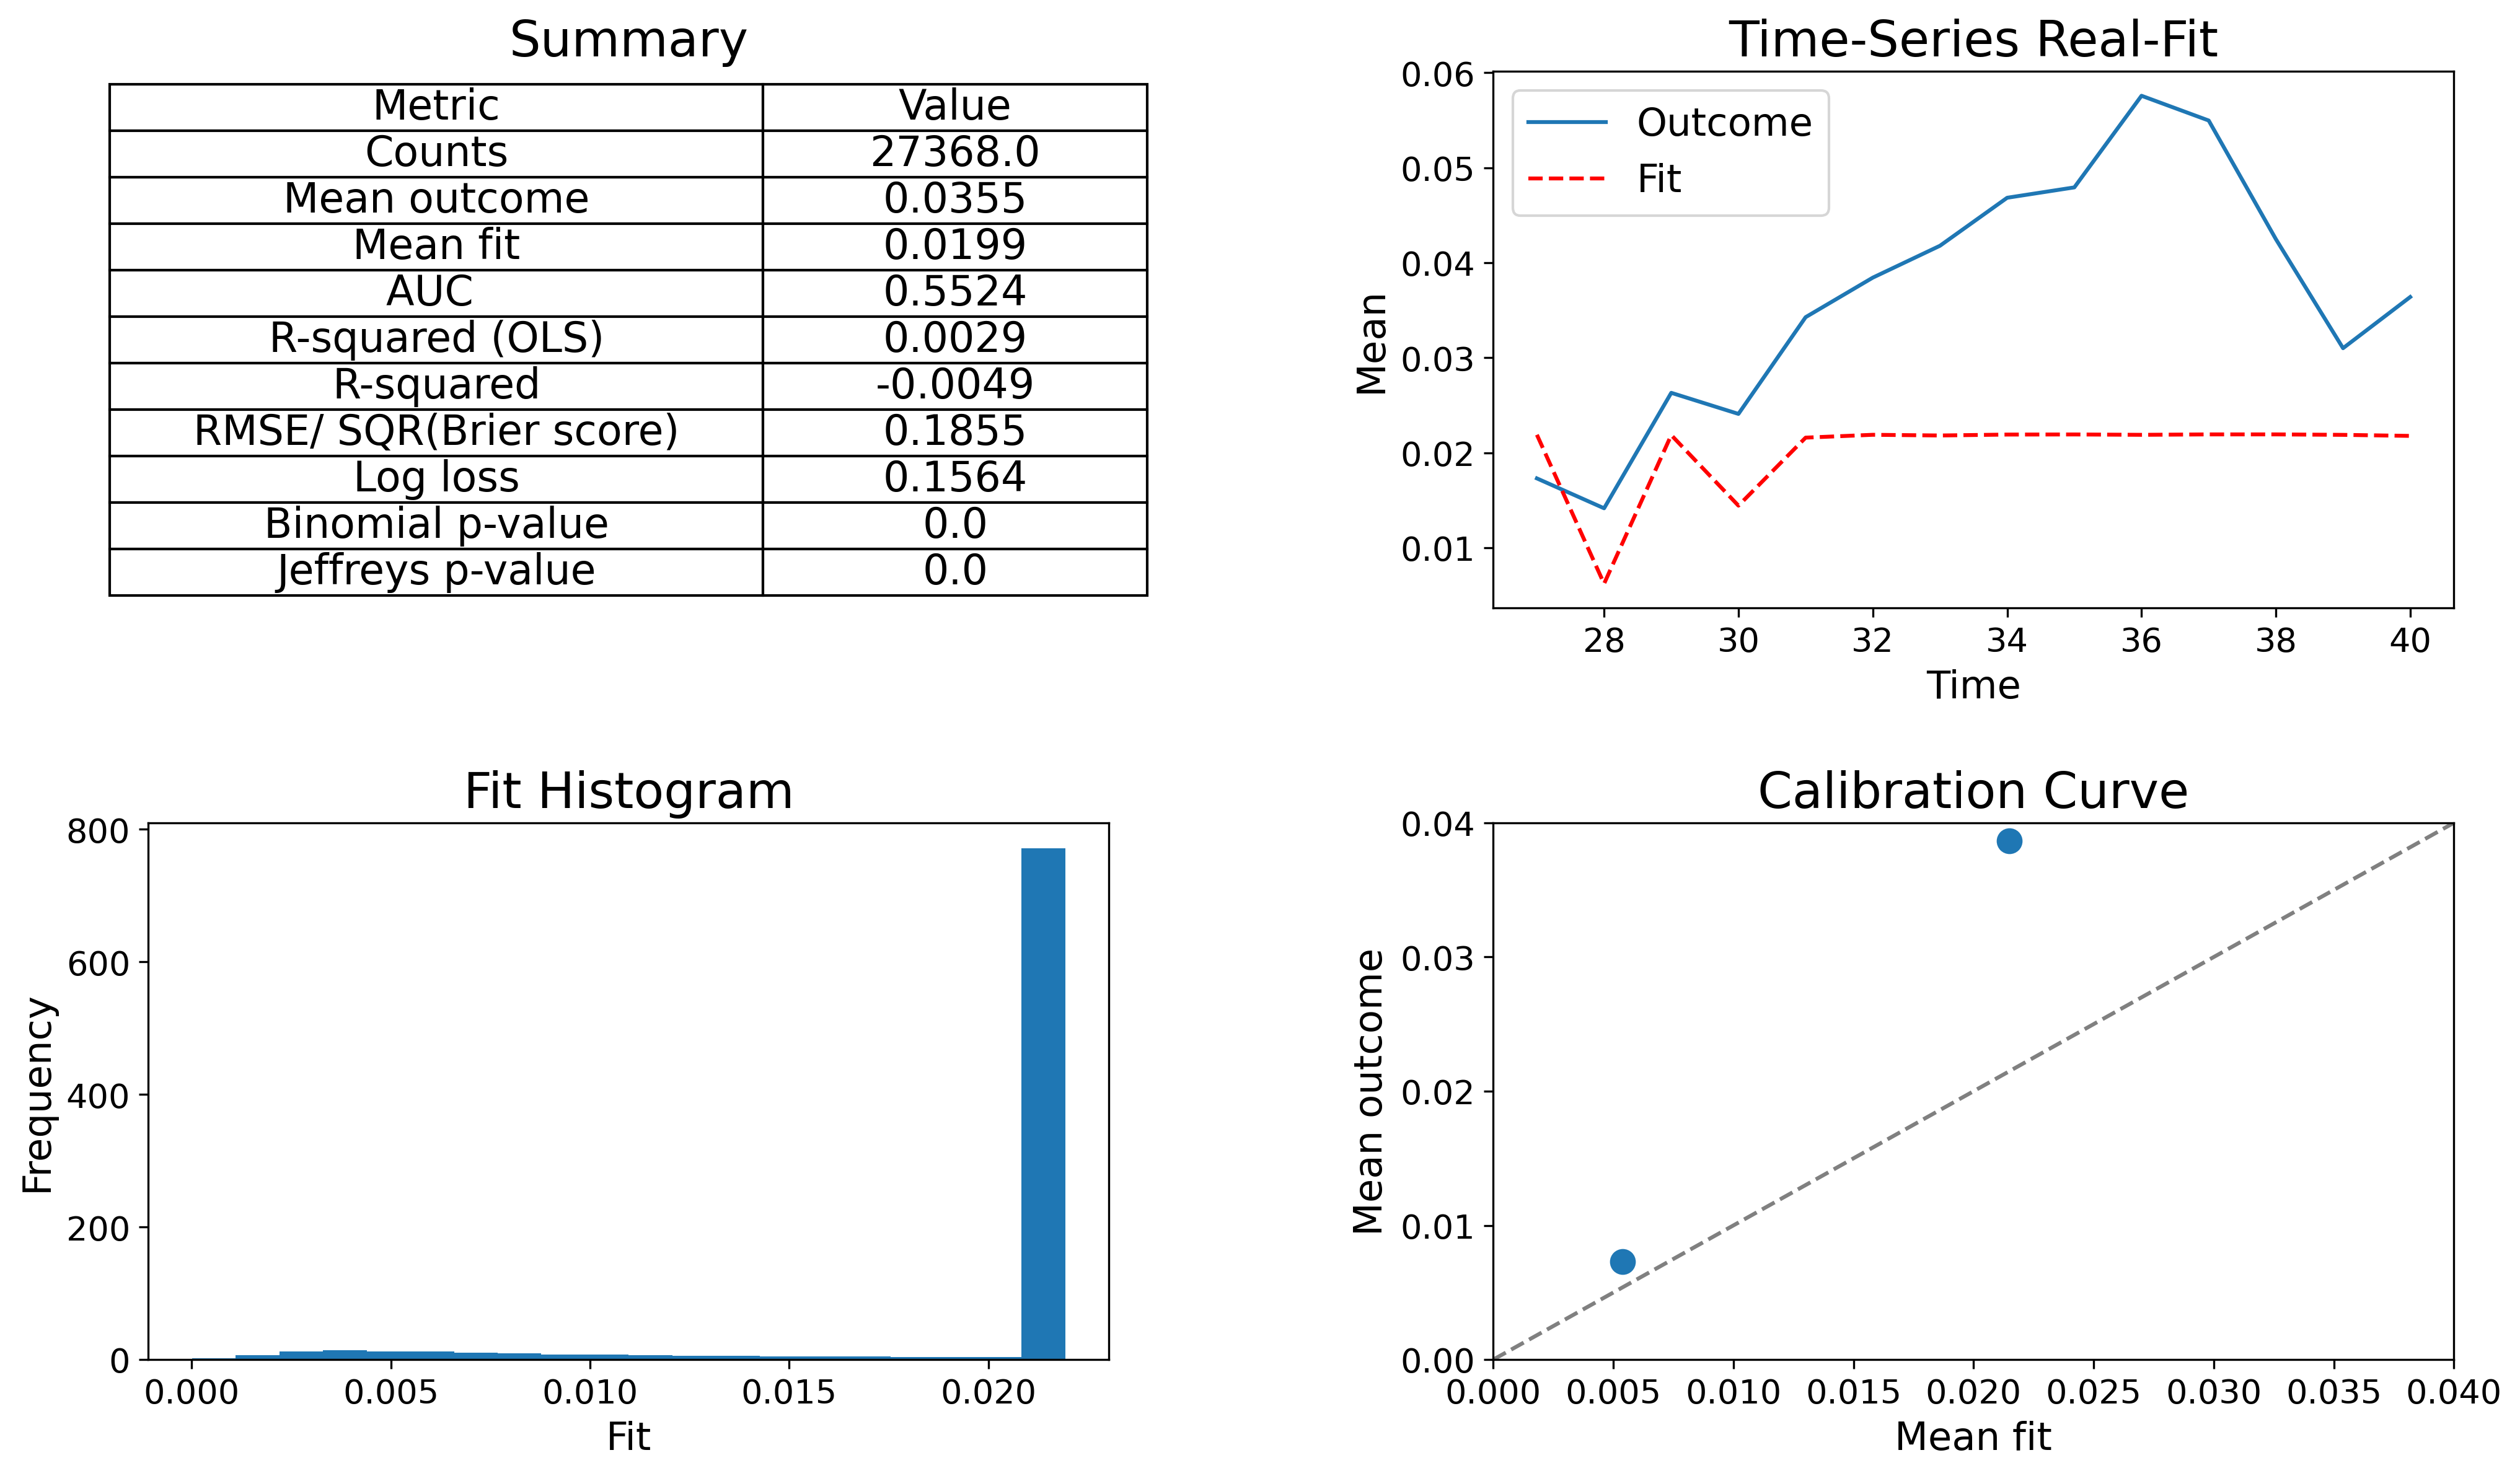

In [35]:
predictions_test = model_nn_best.predict_proba(X_test_scaled)[:,1].T  
validation(predictions_test, y_test, data_test['time'].values)  
AUC_nn_best2 = roc_auc_score(y_test, predictions_test).round(4)  
sqrt_brier_nn_best2 = np.sqrt(brier_score_loss(y_test, predictions_test)).round(4) 


In [36]:
result_table = pd.DataFrame([['Neural Network', AUC_nn, sqrt_brier_nn],  ['Neural Network (CV 1)', AUC_nn_best1, sqrt_brier_nn_best1],  ['Neural Network (CV 2)', AUC_nn_best2, sqrt_brier_nn_best2]  ]).rename(columns={0:'Method', 1:'AUC', 2:'RMSE SQR(Brier score)'})
pd.set_option('display.max_rows', None)  
print(result_table.sort_values(by='AUC', axis=0, ascending=False))

                  Method     AUC  RMSE SQR(Brier score)
1  Neural Network (CV 1)  0.6635                 0.1848
0         Neural Network  0.5956                 0.1857
2  Neural Network (CV 2)  0.5524                 0.1855
